In [2]:
import numpy as np
import matplotlib.pyplot as plt

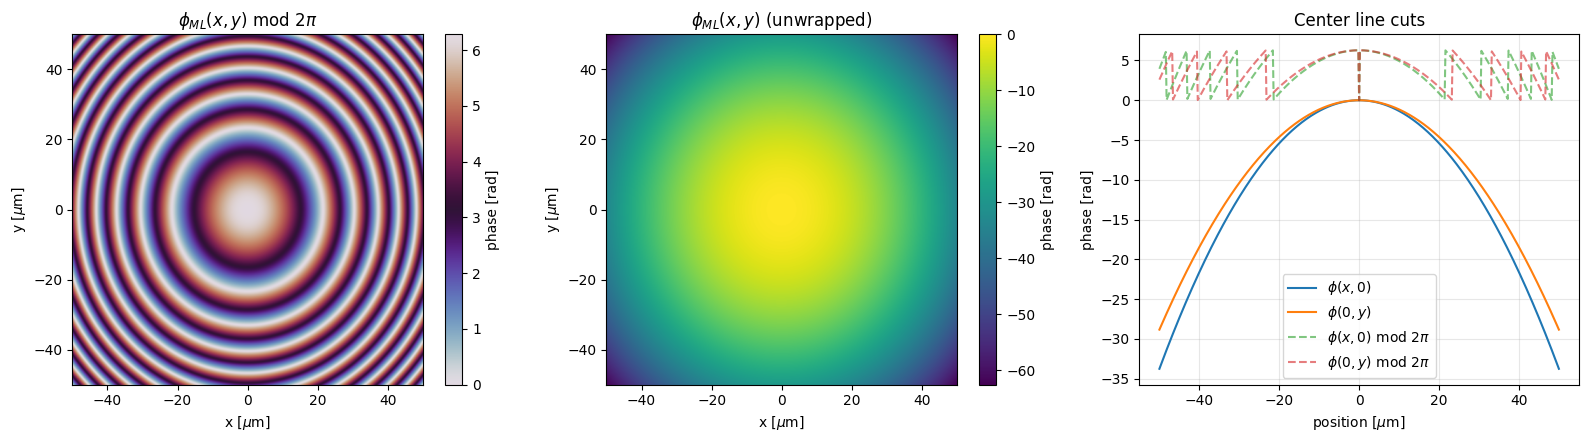

: 

In [ ]:
# Microlens phase: phi(x,y) = -a x^2 - b y^2 (mod 2pi), x,y in um from beam center
a, b = 0.0135003, 0.0115304  # rad/um^2

L = 50  # half-width of plotted region [um]
x = np.linspace(-L, L, 501)
y = np.linspace(-L, L, 501)
X, Y = np.meshgrid(x, y)

phi = -a * X**2 - b * Y**2
phi_wrapped = np.mod(phi, 2 * np.pi)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Wrapped 2D phase map
im = axes[0].imshow(phi_wrapped, extent=[-L, L, -L, L], origin='lower', cmap='twilight')
axes[0].set_title(r'$\phi_{ML}(x,y)$ mod $2\pi$')
axes[0].set_xlabel(r'x [$\mu$m]')
axes[0].set_ylabel(r'y [$\mu$m]')
fig.colorbar(im, ax=axes[0], label='phase [rad]')

# Unwrapped 2D phase map
im2 = axes[1].imshow(phi, extent=[-L, L, -L, L], origin='lower', cmap='viridis')
axes[1].set_title(r'$\phi_{ML}(x,y)$ (unwrapped)')
axes[1].set_xlabel(r'x [$\mu$m]')
axes[1].set_ylabel(r'y [$\mu$m]')
fig.colorbar(im2, ax=axes[1], label='phase [rad]')

# 1D cuts through the center
axes[2].plot(x, -a * x**2, label=r'$\phi(x, 0)$')
axes[2].plot(y, -b * y**2, label=r'$\phi(0, y)$')
axes[2].plot(x, np.mod(-a * x**2, 2 * np.pi), '--', alpha=0.6, label=r'$\phi(x, 0)$ mod $2\pi$')
axes[2].plot(y, np.mod(-b * y**2, 2 * np.pi), '--', alpha=0.6, label=r'$\phi(0, y)$ mod $2\pi$')
axes[2].set_xlabel(r'position [$\mu$m]')
axes[2].set_ylabel('phase [rad]')
axes[2].set_title('Center line cuts')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()